In [88]:
import math
import random

In [89]:
class Value:
  def __init__(self, value:int, _children={}, _op='', label=""):
    self.value = value
    self.grad = 0
    self._backward = lambda:None # Leaf Node?
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.value})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.value + other.value, (self, other), '+')
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.value * other.value, (self, other), '*')

    def _backward():
      self.grad += other.value * out.grad
      other.grad += self.value * out.grad

    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "int/float"
    out = Value(self.value**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.value ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __radd__(self, other):
    return self + other

  def tanh(self):
    x = self.value
    ex = math.exp(x)
    emx = math.exp(-x)
    t = (ex - emx) / (ex + emx)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def topo_sort(v):
      if v not in visited:
          visited.add(v)
          for child in v._prev:
              topo_sort(child)
          topo.append(v)
    topo_sort(self)
    self.grad = 1.0
    for node in topo[::-1]:
      node._backward()


In [90]:
from graphviz import Digraph
def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.value, n.grad), shape='record')
    if n._op:
      dot.node(name=uid+n._op, label=n._op)
      dot.edge(uid+n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2))+n2._op)

  return dot

# Trace function
it is a DFS traversal that constructs the graph
# Graph
This approach uses 2 sets:
1. nodes set of form `[n1, n2, n3]`
2. edges set of form `[(n1, n2) , (n2, n3), (n3, n4)]`


In [91]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1 ; x1w1.label = 'x1w1'
x2w2 = x2 * w2 ; x2w2.label = 'x2w2'
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'
y = x1w1_x2w2 + b ; y.label= 'y'
o = y.tanh() ; o.label = 'o'

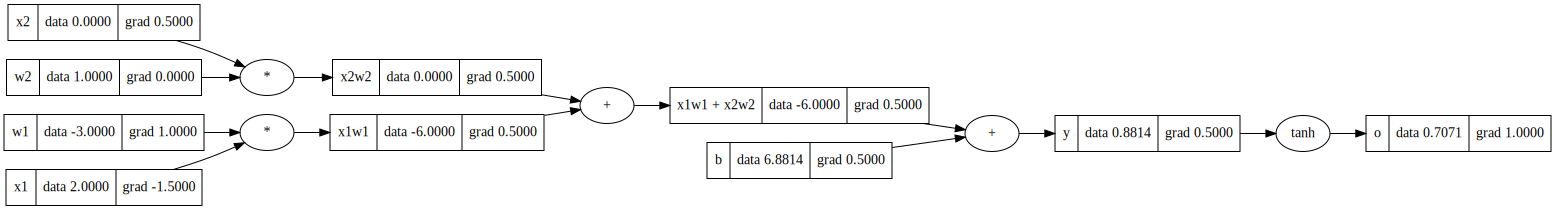

In [92]:
o.backward()
draw_dot(o)

In [93]:
class Neuron:
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    activation = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = activation.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

In [94]:
class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

In [95]:
class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [138]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.44053983378615047)

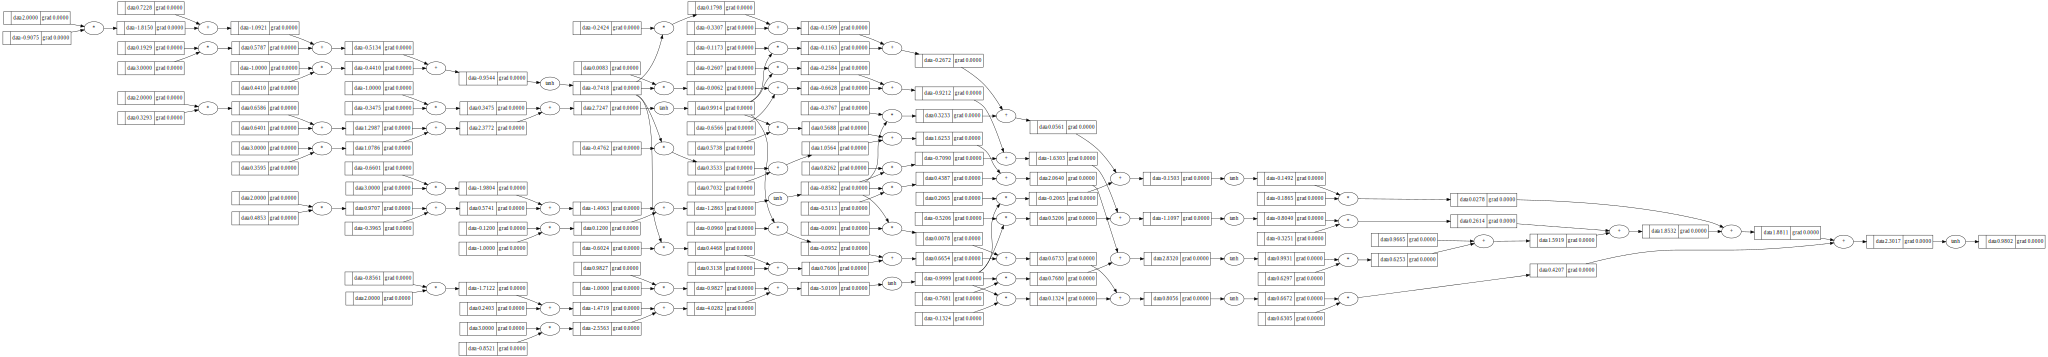

In [97]:
draw_dot(n(x))

In [184]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [188]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])

In [189]:
for k in range(100):
  y_pred = [n(x) for x in xs]
  loss = sum((y_out - y_true)**2 for y_true, y_out in zip(ys, y_pred)) # Fwd pass

  for p in n.parameters():
    p.grad = 0.0 # Zero Grad

  loss.backward() # bwd pass

  for p in n.parameters():
    p.value += -0.1 * p.grad # Update params

  if k%10 == 0:
    print(k, "LOSS = ", loss.value) # Print loss

0 LOSS =  5.650244852413565
10 LOSS =  0.0018120480707125494
20 LOSS =  0.0016530577803543708
30 LOSS =  0.0015209638834166514
40 LOSS =  0.0014094052152994318
50 LOSS =  0.0013138845753055723
60 LOSS =  0.0012311322303005703
70 LOSS =  0.0011587135912100655
80 LOSS =  0.0010947783473361351
90 LOSS =  0.0010378949246844654
